# Olist Delivery Intelligence — Exploratory Data Analysis

We will dive into insights about delivery delay patterns in the Olist e-commerce dataset.  
Each follows: **question → evidence → business implication.**

**Prerequisites:** Run `python src/load_data.py` then `python src/feature.py` first.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

df = pd.read_csv("../data/olist_processed.csv")
print(f"{len(df):,} rows loaded")
print(f"Delay rate: {df['delayed'].mean()*100:.1f}%")

110,781 rows loaded
Delay rate: 6.6%


## Data Quality Check

Verify no orders have `shipping_days < 0` (delivered before carrier pickup — a timestamp error). If any exist the pipeline needs to be re-run.

In [ ]:
neg = (df["shipping_days"] < 0).sum()
assert neg == 0, f"{neg} rows have negative shipping_days — re-run src/feature.py"
print(f"{len(df):,} rows loaded, shipping_days clean")

# 1) Are delays seasonal or constant year-round

If delays spike in specific months, the platform can pre-adjust estimated delivery dates during those windows rather than using a flat buffer all year.

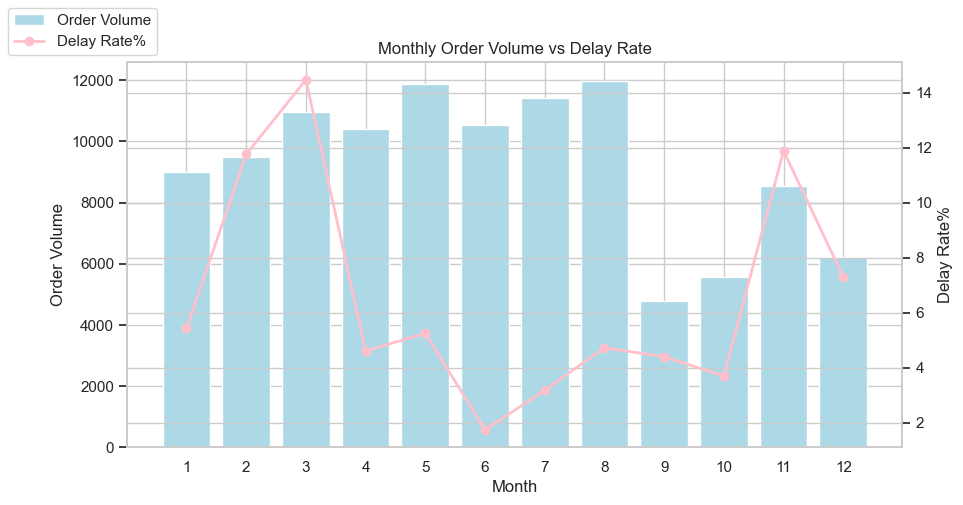

Peak delay in month 3 (14.5%)


In [3]:
monthly = df.groupby('purchase_month')['delayed'].agg(['mean','count'])
monthly.columns = ['delay_rate', 'n_orders']

fig, ax1 = plt.subplots(figsize=(10,5))
ax2 = ax1.twinx()

ax1.bar(monthly.index, monthly['n_orders'], color='lightblue', label='Order Volume')
ax2.plot(monthly.index, monthly['delay_rate']*100, color='pink', marker='o', linewidth=2, label='Delay Rate%')

ax1.set_xlabel('Month')
ax1.set_ylabel('Order Volume')
ax2.set_ylabel('Delay Rate%')
ax1.set_xticks(range(1,13))
fig.legend(loc='upper left')
plt.title('Monthly Order Volume vs Delay Rate')
plt.show()

peak = (monthly['delay_rate']*100).idxmax()
print(f"Peak delay in month {peak} ({monthly.loc[peak,'delay_rate']*100:.1f}%)")


March and November stand out as the two delay hotspots — 14.5% and ~12% respectively. Both align with major Brazilian shopping events: post-Carnival recovery in March and Black Friday surge in November. Meanwhile, mid-year months like June run at just ~2%, showing the logistics infrastructure works fine under normal load. 

# 2)Does shipping distance affect the delays?

We use the absolute difference between 2-digit seller and customer zip prefixes as a distance proxy. Brazilian CEPs are geographically structured - the first digits encode macro-regions.

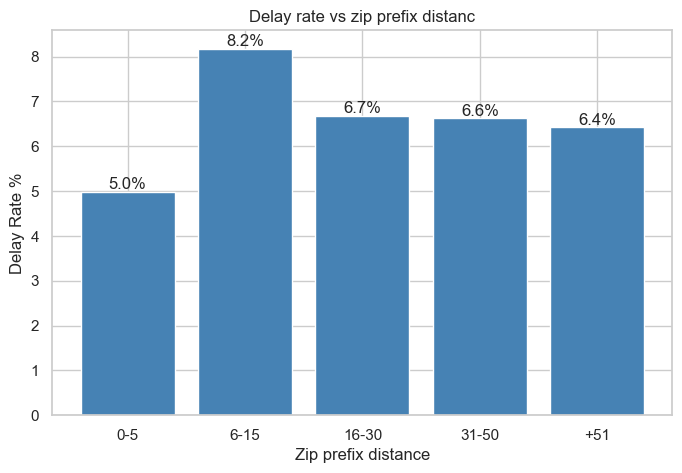

In [4]:
bins = [0,5,15,30,50,100]
labels = ["0-5","6-15","16-30","31-50","+51"]
df["distance_bin"] = pd.cut(df["zip_distance_proxy"],bins=bins, labels=labels, right=True)

dist = df.groupby("distance_bin",observed=True)['delayed'].agg(['mean','count'])
dist.columns = ['delay_rate','n_orders']

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(dist.index, dist["delay_rate"]*100,color= 'steelblue')
ax.bar_label(bars,fmt="%.1f%%")
ax.set_xlabel("Zip prefix distance")
ax.set_ylabel("Delay Rate %")
ax.set_title("Delay rate vs zip prefix distanc")
plt.show()

df.drop(columns=["distance_bin"],inplace=True)

Short-distance orders (0–5) delay the least at 5%. Same-city deliveries, makes sense. The mid-range bucket (6–15) spikes to 8.2% — highest of any group — but that doesn't mean medium distance is the problem. Brazilian CEPs don't map linearly to geography. A prefix difference of 10 could be a neighbouring city or a completely different region. What the pattern actually shows is that our zip prefix proxy isn't a strong standalone predictor.

For longer distances (16+), delays flatten around 6.5%. The platform likely already pads those estimates with generous buffers, so the raw distance matters less. The state-to-state route analysis in the next section gives a far cleaner geographic signal — and SHAP confirmed `zip_distance_proxy` sits in the mid-tier of feature importance behind seasonality, estimated days, and customer state.

# 3)Which state-to-state routes delay the most?

The zip prefix proxy showed its limitations. We have actual seller_state and customer_state columns - a heatmap of delay rates across the top routes gives real geographic signal

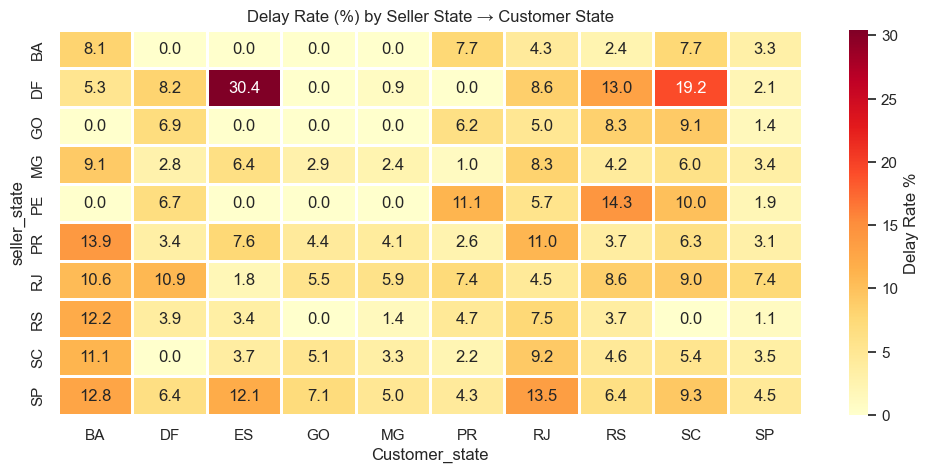

In [5]:
#count orders per route and will be only those routes with 200+ orders
route_count = df.groupby(["seller_state","customer_state"]).size().reset_index(name="n_orders")
high_volume = route_count[route_count["n_orders"]>=200]

top_seller_state = df["seller_state"].value_counts().head(10).index.tolist()
top_customer_state = df["customer_state"].value_counts().head(10).index.tolist()

subset = df[
    df["seller_state"].isin(top_seller_state) &
    df["customer_state"].isin(top_customer_state)
]

pivot = subset.groupby(["seller_state","customer_state"])["delayed"].mean().unstack()*100

fig,ax = plt.subplots(figsize=(12,5))
sns.heatmap(pivot, fmt=".1f",annot=True, cmap="YlOrRd", linewidths=1, cbar_kws={"label":"Delay Rate %"},ax=ax)
ax.set_title("Delay Rate (%) by Seller State \u2192 Customer State")
ax.set_ylabel("seller_state")
ax.set_xlabel("Customer_state")
plt.show()


Route is the biggest factor here. DF sellers delay at 30.4% to ES, 19.2% to SC. Brasília doesn't have much logistics infrastructure — not many carriers to choose from. SP→RJ sits at 13.5%, which is high for a short, busy corridor. Probably capacity, or estimates that were optimistic from the start.

 SP→SP is 4.5%. Same-state stays below 5% pretty much everywhere.
The zip proxy analysis missed most of this. 

The route-level variation is bigger, and it's tied to actual geography — not which digits happen to share a prefix. 

# 4)Does shipment difficulty(weight + freight cost) predict delays?

Product weight and freight cost are related - heavier items cost more to ship. Individually, neither shows a dramatic effect on delays.The question is whether combining them reveals a clearer pattern: do heavy items on expensive routes delay the most?



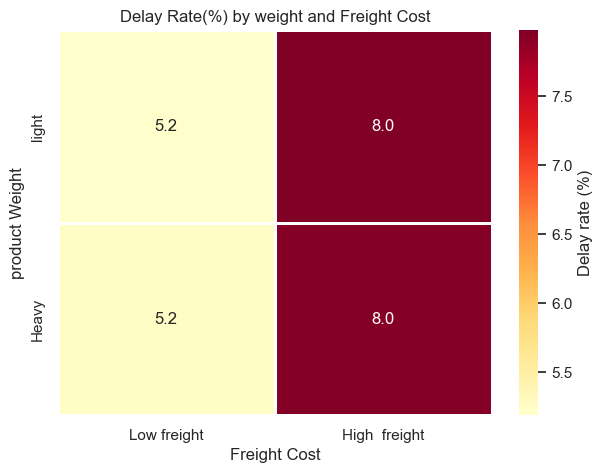

In [6]:
df["weight_bin"] = pd.qcut(df["product_weight_g"],q=2, labels=["light","Heavy"])
df["freight_bin"] = pd.qcut(df["freight_value"],q=2, labels=["Low freight","High  freight"])

heatmap_data = df.groupby(["weight_bin", "freight_bin"],observed = True)["delayed"].mean()*100
heatmap_data = heatmap_data.unstack()

fig,ax = plt.subplots(figsize=(7,5))
sns.heatmap(heatmap_data,annot=True,fmt=".1f",cmap="YlOrRd", cbar_kws={"label": "Delay rate (%)"},linewidths=1 , ax=ax)
ax.set_title("Delay Rate(%) by weight and Freight Cost")
ax.set_ylabel("product Weight")
ax.set_xlabel("Freight Cost")
plt.show()

df.drop(columns= ["weight_bin","freight_bin"],inplace= True)

We expected heavy items on expensive routes to be the worst combination. The heatmap disagrees — weight barely registers. Light or heavy, low freight orders delay at 5.2% and high freight orders at 8.0%. The gap is entirely about freight cost, which makes sense: carriers already price in weight, distance, and route difficulty. By the time freight cost is in the model, weight has nothing left to add.

SHAP confirmed this: `freight_value` carries meaningful importance while `product_weight_g` contributes very little on its own. Both features were kept in the final model since weight still contributes marginally through interactions, but freight cost is the one doing the real work.

# 5)Are delays concentrated among specific sellers?

If delays are systemic, you need platform-wide changes. If they are concentrated in a few sellers, targeted interventions are more efficient

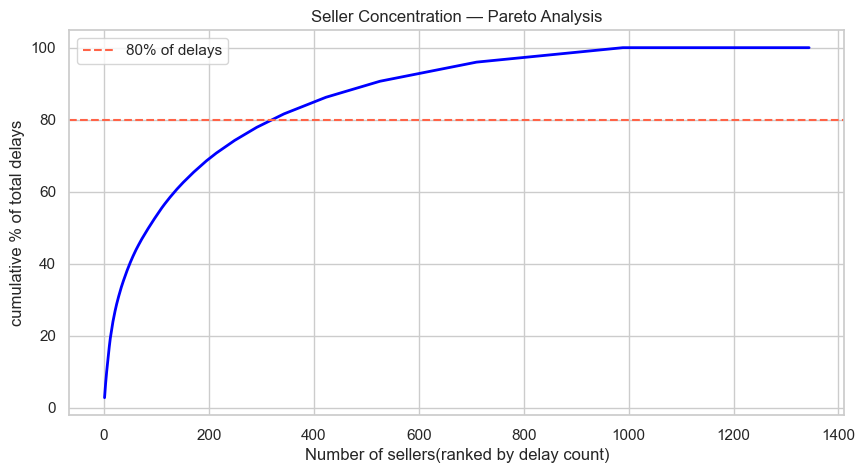

321 sellers (24%) cause 80% of all delays
Out of 1,344 active sellers (10+ orders)


In [7]:
stats = df.groupby("seller_id")["delayed"].agg(["count","sum"])
stats.columns = ["total","delays"]
active = stats[stats["total"]>=10].sort_values("delays",ascending=False)

total_delays = active["delays"].sum()
active["cumulative_pct"] = active["delays"].cumsum()/ total_delays *100

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(range(1, len(active)+1),active["cumulative_pct"].values, color="blue",linewidth=2)
ax.axhline(y=80,color="tomato",linestyle="--", label= "80% of delays")
ax.set_xlabel("Number of sellers(ranked by delay count)")
ax.set_ylabel("cumulative % of total delays")
ax.set_title("Seller Concentration \u2014 Pareto Analysis")
ax.legend()
plt.show()

sellers_80 = (active["cumulative_pct"] <= 80).sum() + 1
print(f"{sellers_80:,} sellers ({sellers_80/len(active)*100:.0f}%) cause 80% of all delays")
print(f"Out of {len(active):,} active sellers (10+ orders)")

321 out of 1,344 active sellers account for 80% of all delays. The curve is steep — a handful of sellers at the top are doing most of the damage. This isn't a logistics problem. It's a seller problem.
Which means the lever isn't platform-wide. The platform could go after these 321 directly: SLA warnings, fulfillment coaching, rerouting their orders through faster carriers. Fix the worst 10% and the overall delay rate likely drops by a third. That's a lot of improvement for a very targeted intervention.

# 6) Are sellers overpromising delivery speed?

If sellers who commit to very short delivery windows delay at a much higher rate, the problem is expectation-setting, not shipping. The fix would be constraining how aggressively sellers can advertise delivery dates.

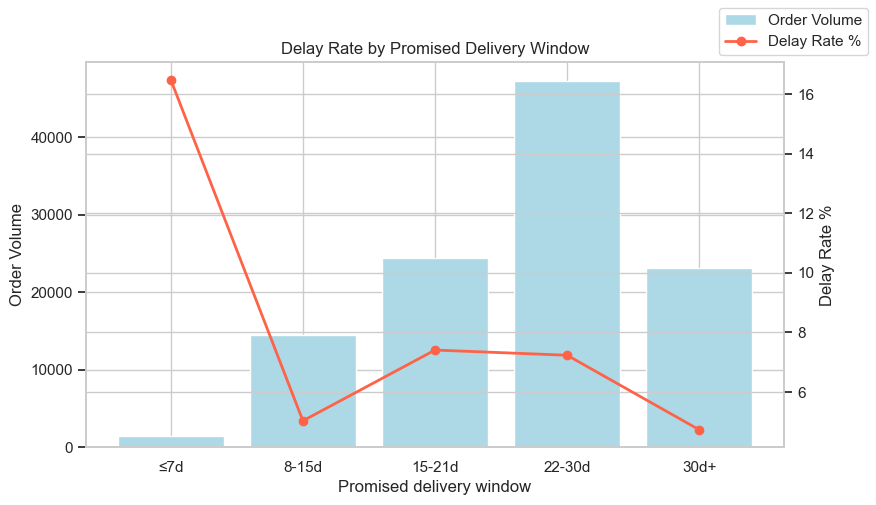

     ≤7d    1,408 orders   16.5% delay rate
   8-15d   14,533 orders    5.0% delay rate
  15-21d   24,424 orders    7.4% delay rate
  22-30d   47,302 orders    7.2% delay rate
    30d+   23,114 orders    4.7% delay rate


In [8]:
max_est = df["estimated_days"].max() + 1
bins = [0, 7, 15, 21, 30, max_est]
labels = ["≤7d", "8-15d", "15-21d", "22-30d", "30d+"]
df["est_bin"] = pd.cut(df["estimated_days"], bins=bins, labels=labels, right=True)

est = df.groupby("est_bin", observed=True)["delayed"].agg(["mean", "count"])
est.columns = ["delay_rate", "n_orders"]

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()
ax1.bar(est.index, est["n_orders"], color="lightblue", label="Order Volume")
ax2.plot(est.index, est["delay_rate"] * 100, color="tomato", marker="o", linewidth=2, label="Delay Rate %")
ax1.set_xlabel("Promised delivery window")
ax1.set_ylabel("Order Volume")
ax2.set_ylabel("Delay Rate %")
fig.legend(loc="upper right")
ax1.set_title("Delay Rate by Promised Delivery Window")
plt.show()

for label in labels:
    if label in est.index:
        row = est.loc[label]
        print(f"  {label:>6s}  {row['n_orders']:>7,.0f} orders  {row['delay_rate']*100:>5.1f}% delay rate")

df.drop(columns=["est_bin"], inplace=True)

Orders with very short promised windows (≤7 days) delay at 16.5% — more than 3× the overall rate. Sellers offering aggressive timelines are setting expectations they can't reliably meet. The 30d+ bucket sits at just 4.7%, not because those orders are handled better, but because the buffer is big enough to absorb most slippage.

The business lever here is constraining how short a seller can set their estimated delivery date. Enforcing a minimum window based on route and seller history would cut a significant share of delays without touching logistics at all — it's purely an expectation-management fix. `estimated_days` being the second-highest SHAP feature confirms it's one of the strongest predictors in the model.